In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import h5py
import gc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
base_path = Path("./sample_data")
master_csv = Path("master_active_power.csv")
window_csv = Path("window_features.csv")

def normalize_name(name):
    return str(name).lower().strip().replace(" ", "_").replace("-", "_")

def categorize_appliance(appliance_name):
    name = normalize_name(appliance_name)
    if name in {"fridge", "freezer"}:
        return "cold"
    elif name in {"washing_machine", "tumble_dryer"}:
        return "laundry"
    elif name in {"oven", "electric_stove", "electric_stove_oven", "rechaud", "dishwasher"}:
        return "cooking"
    elif name == "boiler":
        return "water_heating"
    elif name in {"electric_vehicle_1", "electric_vehicle_2"}:
        return "ev"
    elif name == "dehumidifier":
        return "climate"
    elif name in {"cii_adapter", "cii-adapter"}:
        return "adapter"
    else:
        return "other"

In [3]:
def process_file_in_chunks(file_path, building_name, appliance_name, category, write_header, chunk_size=200_000):
    with h5py.File(file_path, "r") as f:
        cols = [x.decode("utf-8") for x in f["data/block0_items"][:]]
        ds = f["data/block0_values"]
        active_idx = [i for i, c in enumerate(cols) if "Active Power" in c]
        active_cols = [cols[i] for i in active_idx]

        n_rows = ds.shape[0]
        for start in range(0, n_rows, chunk_size):
            end = min(start + chunk_size, n_rows)
            arr = ds[start:end, active_idx].astype(np.float32, copy=False)
            chunk_df = pd.DataFrame(arr, columns=active_cols)
            chunk_df["building"] = building_name
            chunk_df["appliance"] = appliance_name
            chunk_df["category"] = category
            chunk_df.to_csv(master_csv, mode="a", header=write_header, index=False)
            write_header = False
            del arr, chunk_df
            gc.collect()
    return write_header

In [4]:
rows = []
for building_dir in sorted(base_path.glob("building_*")):
    for file_path in sorted(building_dir.glob("*.h5")):
        appliance = file_path.stem
        rows.append({
            "building": building_dir.name,
            "appliance": appliance,
            "category": categorize_appliance(appliance),
            "path": str(file_path)
        })

inventory_df = pd.DataFrame(rows)
print(inventory_df["category"].value_counts())
print("other appliances:", inventory_df.loc[inventory_df["category"] == "other", "appliance"].unique())

category
cooking          10
laundry           6
adapter           4
cold              4
water_heating     3
ev                2
climate           1
Name: count, dtype: int64
other appliances: <ArrowStringArray>
[]
Length: 0, dtype: str


In [11]:


CATEGORY_ORDER = ["cold", "laundry", "cooking", "water_heating", "ev", "climate", "adapter"]

def load_active_power_df(file_path):
    with h5py.File(file_path, "r") as f:
        cols = [x.decode("utf-8") for x in f["data/block0_items"][:]]
        values = f["data/block0_values"][:]

    df = pd.DataFrame(values, columns=cols)

    active_cols = [c for c in df.columns if "Active Power" in c]
    if not active_cols:
        raise ValueError(f"No active power columns found in {file_path}")

    keep_cols = active_cols[:3]
    out = df[keep_cols].copy()

    rename_map = {}
    if len(keep_cols) >= 1:
        rename_map[keep_cols[0]] = "L1"
    if len(keep_cols) >= 2:
        rename_map[keep_cols[1]] = "L2"
    if len(keep_cols) >= 3:
        rename_map[keep_cols[2]] = "L3"

    out = out.rename(columns=rename_map)

    for col in ["L1", "L2", "L3"]:
        if col not in out.columns:
            out[col] = 0.0

    out = out[["L1", "L2", "L3"]].astype(np.float32)
    return out

def build_building_category_targets(building_name, inventory_df):
    building_rows = inventory_df[inventory_df["building"] == building_name].copy()

    category_series = {}
    min_len = None

    for _, row in building_rows.iterrows():
        category = row["category"]
        if category == "other":
            continue

        df = load_active_power_df(row["path"])
        total_power = df["L1"].to_numpy() + df["L2"].to_numpy() + df["L3"].to_numpy()

        if min_len is None:
            min_len = len(total_power)
        else:
            min_len = min(min_len, len(total_power))

        if category not in category_series:
            category_series[category] = []
        category_series[category].append(total_power)

    if min_len is None:
        return None, None

    trimmed = {}
    for cat, signals in category_series.items():
        trimmed[cat] = [s[:min_len] for s in signals]

    category_targets = {}
    for cat in CATEGORY_ORDER:
        if cat in trimmed:
            category_targets[cat] = np.sum(trimmed[cat], axis=0).astype(np.float32)
        else:
            category_targets[cat] = np.zeros(min_len, dtype=np.float32)

    agg = np.zeros(min_len, dtype=np.float32)
    for cat in CATEGORY_ORDER:
        agg += category_targets[cat]

    target_df = pd.DataFrame(category_targets)
    agg_df = pd.DataFrame({"aggregate": agg})

    return agg_df, target_df

def compute_window_features(w):
    diff = np.diff(w)

    feats = {
        "agg_mean": float(np.mean(w)),
        "agg_std": float(np.std(w)),
        "agg_max": float(np.max(w)),
        "agg_min": float(np.min(w)),
        "agg_rms": float(np.sqrt(np.mean(np.square(w)))),
        "agg_p25": float(np.percentile(w, 25)),
        "agg_p50": float(np.percentile(w, 50)),
        "agg_p75": float(np.percentile(w, 75)),
        "agg_range": float(np.max(w) - np.min(w)),
        "agg_energy": float(np.sum(np.square(w))),
        "agg_abs_diff_mean": float(np.mean(np.abs(diff))) if len(diff) > 0 else 0.0,
        "agg_diff_std": float(np.std(diff)) if len(diff) > 0 else 0.0,
        "agg_num_up": int(np.sum(diff > 10)) if len(diff) > 0 else 0,
        "agg_num_down": int(np.sum(diff < -10)) if len(diff) > 0 else 0,
    }

    return feats


def make_nilm_windows(agg_df, target_df, building_name, category_order, window_size=200, step=100):
    X_rows = []
    Y_rows = []

    agg = agg_df["aggregate"].to_numpy(dtype=np.float32)

    for start in range(0, len(agg) - window_size + 1, step):
        end = start + window_size
        w = agg[start:end]

        x = {"building": building_name}
        x.update(compute_window_features(w))

        y = {"building": building_name}
        for cat in category_order:
            target_w = target_df[cat].iloc[start:end].to_numpy(dtype=np.float32)
            y[f"{cat}_mean"] = float(np.mean(target_w))
            y[f"{cat}_max"] = float(np.max(target_w))

        X_rows.append(x)
        Y_rows.append(y)

    return pd.DataFrame(X_rows), pd.DataFrame(Y_rows)

In [12]:
all_X = []
all_Y = []

for building_name in sorted(inventory_df["building"].unique()):
    agg_df, target_df = build_building_category_targets(building_name, inventory_df)

    if agg_df is None or target_df is None:
        print(f"Skipping {building_name}: no valid categories")
        continue

    X_b, Y_b = make_nilm_windows(
        agg_df=agg_df,
        target_df=target_df,
        building_name=building_name,
        category_order=CATEGORY_ORDER,
        window_size=200,
        step=100
    )

    print(building_name, X_b.shape, Y_b.shape)
    all_X.append(X_b)
    all_Y.append(Y_b)

X_nilm = pd.concat(all_X, ignore_index=True)
Y_nilm = pd.concat(all_Y, ignore_index=True)

X_nilm.to_csv("X_nilm_rich.csv", index=False)
Y_nilm.to_csv("Y_nilm_rich.csv", index=False)

print("Saved:", X_nilm.shape, Y_nilm.shape)
print(X_nilm.head())
print(Y_nilm.head())

building_01 (172040, 15) (172040, 15)
building_02 (20478, 15) (20478, 15)
building_03 (35246, 15) (35246, 15)
building_04 (33248, 15) (33248, 15)
Saved: (261012, 15) (261012, 15)
      building    agg_mean     agg_std      agg_max     agg_min     agg_rms  \
0  building_01  623.249573  351.393341  2019.873779  287.370819  715.484009   
1  building_01  563.039490  233.943390  1127.613525  287.370819  609.707275   
2  building_01  695.906799  161.538971  1080.727295  402.309662  714.409607   
3  building_01  680.395081  262.209259  1204.196899  393.832794  729.171570   
4  building_01  871.685303  311.739014  1516.661621  393.832794  925.751770   

      agg_p25     agg_p50      agg_p75    agg_range   agg_energy  \
0  297.289551  525.287720   937.119263  1732.502930  102383472.0   
1  323.181885  540.864807   696.412476   840.242676   74348592.0   
2  591.364197  693.167480   815.078003   678.417603  102076224.0   
3  461.092224  617.970825   823.758301   810.364136  106338232.0   
4  466

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

feature_cols = [c for c in X_nilm.columns if c != "building"]
X_scaled = X_nilm.copy()
X_scaled[feature_cols] = X_scaled.groupby("building")[feature_cols].transform(
    lambda s: (s - s.mean()) / (s.std() + 1e-8)
)

buildings = sorted(X_scaled["building"].unique())
n_test = max(1, int(len(buildings) * 0.3))
test_buildings = buildings[-n_test:]
train_buildings = buildings[:-n_test]

train_mask = X_scaled["building"].isin(train_buildings)
test_mask = X_scaled["building"].isin(test_buildings)

X_train = X_scaled.loc[train_mask].drop(columns=["building"])
X_test = X_scaled.loc[test_mask].drop(columns=["building"])

Y_train = Y_nilm.loc[train_mask].drop(columns=["building"])
Y_test = Y_nilm.loc[test_mask].drop(columns=["building"])

valid_targets = []
for col in Y_train.columns:
    if Y_train[col].std() > 1e-8 and Y_test[col].std() > 1e-8:
        valid_targets.append(col)

Y_train = Y_train[valid_targets]
Y_test = Y_test[valid_targets]

print("Targets kept:", valid_targets)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=25,
    min_samples_leaf=5
)

model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

pred_df = pd.DataFrame(Y_pred, columns=Y_train.columns, index=Y_test.index)

print("Overall MAE:", mean_absolute_error(Y_test, pred_df))
print("Overall R2:", r2_score(Y_test, pred_df))

for col in Y_test.columns:
    mae = mean_absolute_error(Y_test[col], pred_df[col])
    r2 = r2_score(Y_test[col], pred_df[col])
    mean_true = Y_test[col].mean()
    rel = 100 * mae / mean_true if mean_true != 0 else None
    print(f"{col:20s} MAE={mae:8.2f} mean={mean_true:8.2f} rel%={rel!s:>8} R2={r2:6.3f}")

Targets kept: ['cold_mean', 'cold_max', 'laundry_mean', 'laundry_max', 'cooking_mean', 'cooking_max', 'adapter_mean', 'adapter_max']
Overall MAE: 268.1897449542664
Overall R2: -1.6512035670336918
cold_mean            MAE=   21.63 mean=   19.54 rel%=110.73314000535615 R2=-3.778
cold_max             MAE=   95.64 mean=   40.41 rel%=236.67091681411776 R2=-10.599
laundry_mean         MAE=   99.01 mean=   88.11 rel%=112.3681817497368 R2=-0.066
laundry_max          MAE=  175.46 mean=  157.42 rel%=111.46428227815389 R2=-0.015
cooking_mean         MAE=  109.51 mean=  104.73 rel%=104.56171651630328 R2= 0.155
cooking_max          MAE=  278.77 mean=  247.95 rel%=112.42871323232481 R2= 0.242
adapter_mean         MAE=  530.30 mean=  764.87 rel%=69.33166758032036 R2= 0.416
adapter_max          MAE=  835.20 mean= 1290.35 rel%=64.72642644532532 R2= 0.435


In [9]:
from sklearn.metrics import mean_absolute_error
import pandas as pd

pred_df = pd.DataFrame(Y_pred, columns=Y.columns, index=Y_test.index)

mae_per_target = {}
for col in Y.columns:
    mae_per_target[col] = mean_absolute_error(Y_test[col], pred_df[col])

mae_per_target = pd.Series(mae_per_target).sort_values()
print(mae_per_target)
from sklearn.metrics import r2_score

print("Overall MAE:", mean_absolute_error(Y_test, Y_pred))
print("Overall R2:", r2_score(Y_test, Y_pred))

pred_df = pd.DataFrame(Y_pred, columns=Y.columns, index=Y_test.index)

for col in Y.columns:
    mae = mean_absolute_error(Y_test[col], pred_df[col])
    r2 = r2_score(Y_test[col], pred_df[col])
    mean_true = Y_test[col].mean()
    rel = 100 * mae / mean_true if mean_true != 0 else None
    print(f"{col:20s} MAE={mae:8.2f}  mean={mean_true:8.2f}  rel%={rel!s:>8}  R2={r2:6.3f}")

climate_mean            0.707410
cold_mean              17.611472
ev_mean                31.408656
laundry_mean           39.111283
cooking_mean           55.991945
water_heating_mean    120.188647
adapter_mean          206.583553
dtype: float64
Overall MAE: 67.3718524366508
Overall R2: 0.4434255762416654
cold_mean            MAE=   17.61  mean=   37.45  rel%=47.02801754900117  R2= 0.446
laundry_mean         MAE=   39.11  mean=   28.22  rel%=138.61121274010472  R2= 0.278
cooking_mean         MAE=   55.99  mean=   57.55  rel%=97.29713277856524  R2= 0.454
water_heating_mean   MAE=  120.19  mean=  203.43  rel%=59.08074775072282  R2= 0.686
ev_mean              MAE=   31.41  mean=   33.70  rel%=93.19041006602619  R2= 0.499
climate_mean         MAE=    0.71  mean=    0.43  rel%=164.27267028532097  R2= 0.127
adapter_mean         MAE=  206.58  mean=  570.55  rel%=36.20774550672273  R2= 0.615


In [19]:
if master_csv.exists():
    master_csv.unlink()

header_needed = True
for _, row in inventory_df.iterrows():
    header_needed = process_file_in_chunks(
        file_path=Path(row["path"]),
        building_name=row["building"],
        appliance_name=row["appliance"],
        category=row["category"],
        write_header=header_needed
    )
    print("Processed", row["appliance"])

Processed boiler
Processed cii-adapter
Processed dishwasher
Processed freezer
Processed oven
Processed rechaud
Processed washing_machine
Processed boiler
Processed cii-adapter
Processed dehumidifier
Processed dishwasher
Processed electric_stove
Processed fridge
Processed washing_machine
Processed boiler
Processed cii-adapter
Processed dishwasher
Processed electric_stove
Processed fridge
Processed oven
Processed tumble_dryer
Processed washing_machine
Processed cii-adapter
Processed dishwasher
Processed electric_stove_oven
Processed electric_vehicle_1
Processed electric_vehicle_2
Processed fridge
Processed tumble_dryer
Processed washing_machine


In [21]:
def safe_window_features(df_path, window_size=200, step=100, max_windows=500_000):
    features = []
    for chunk_num, chunk in enumerate(pd.read_csv(df_path, chunksize=500_000), start=1):
        print(f"chunk {chunk_num}, rows={len(chunk)}")
        power_cols = [c for c in chunk.columns if c.startswith("Active Power")]
        for col in power_cols:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
        chunk = chunk.dropna(subset=power_cols + ["category"])
        if len(chunk) < window_size:
            continue
        arr = chunk[power_cols].to_numpy(dtype=np.float32)
        cats = chunk["category"].to_numpy()
        for start in range(0, len(chunk) - window_size + 1, step):
            w = arr[start:start + window_size]
            features.append({
                "l1_mean": float(np.mean(w[:, 0])),
                "l1_std": float(np.std(w[:, 0])),
                "l1_max": float(np.max(w[:, 0])),
                "l2_mean": float(np.mean(w[:, 1])) if w.shape[1] > 1 else np.nan,
                "l3_mean": float(np.mean(w[:, 2])) if w.shape[1] > 2 else np.nan,
                "category": cats[start]
            })
            if len(features) >= max_windows:
                break
        if len(features) >= max_windows:
            break
    return pd.DataFrame(features)

In [ ]:
features_df = safe_window_features(master_csv, window_size=200, step=100, max_windows=500_000)
features_df.to_csv(window_csv, index=False)

X = features_df[["l1_mean", "l1_std", "l1_max", "l2_mean", "l3_mean"]].fillna(0)
y = features_df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", rf.score(X_test, y_test))

chunk 1, rows=500000
chunk 2, rows=500000
chunk 3, rows=500000
chunk 4, rows=500000
chunk 5, rows=500000
chunk 6, rows=500000
chunk 7, rows=500000
chunk 8, rows=500000
chunk 9, rows=500000
chunk 10, rows=500000
chunk 11, rows=500000
chunk 12, rows=500000
chunk 13, rows=500000
chunk 14, rows=500000
chunk 15, rows=500000
chunk 16, rows=500000
chunk 17, rows=500000
chunk 18, rows=500000
chunk 19, rows=500000
chunk 20, rows=500000
chunk 21, rows=500000
chunk 22, rows=500000
chunk 23, rows=500000
chunk 24, rows=500000
chunk 25, rows=500000
chunk 26, rows=500000
chunk 27, rows=500000
chunk 28, rows=500000
chunk 29, rows=500000
chunk 30, rows=500000
chunk 31, rows=500000
chunk 32, rows=500000
chunk 33, rows=500000
chunk 34, rows=500000
chunk 35, rows=500000
chunk 36, rows=500000
chunk 37, rows=500000
chunk 38, rows=500000
chunk 39, rows=500000
chunk 40, rows=500000
chunk 41, rows=500000
chunk 42, rows=500000
chunk 43, rows=500000
chunk 44, rows=500000
chunk 45, rows=500000
chunk 46, rows=5000

: 

In [8]:
# import pandas as pd
# from pathlib import Path

# src_csv = Path("master_active_power.csv")
# parquet_path = Path("master.parquet")
# gz_path = Path("master_active_power.csv.gz")

# chunk_iter = pd.read_csv(src_csv, chunksize=100_000)

# try:
#     import pyarrow as pa
#     import pyarrow.parquet as pq

#     writer = None
#     for i, chunk in enumerate(chunk_iter, start=1):
#         table = pa.Table.from_pandas(chunk, preserve_index=False)
#         if writer is None:
#             writer = pq.ParquetWriter(parquet_path, table.schema)
#         writer.write_table(table)

#         if i % 20 == 0:
#             print(f"Processed {i} chunks to parquet...")

#     if writer is not None:
#         writer.close()
#     print(f"Parquet ready: {parquet_path.resolve()}")

# except ModuleNotFoundError:
#     print("pyarrow is not installed. Creating compressed CSV instead...")

#     first = True
#     for i, chunk in enumerate(pd.read_csv(src_csv, chunksize=100_000), start=1):
#         chunk.to_csv(gz_path, mode="w" if first else "a", index=False, header=first, compression="gzip")
#         first = False
#         if i % 20 == 0:
#             print(f"Processed {i} chunks to gzip CSV...")

#     print(f"Compressed CSV ready: {gz_path.resolve()}")
#     print("If you want parquet later, run: pip install pyarrow")

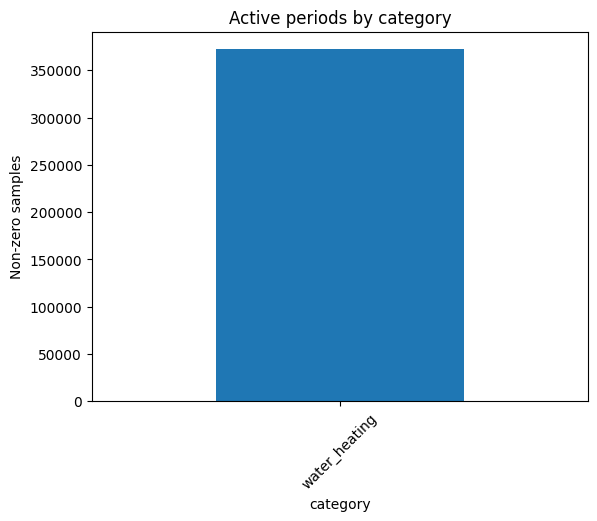

In [9]:
if "df_sample" not in globals():
    df_sample = pd.read_csv("master_active_power.csv", nrows=1_000_000)

active_df = df_sample[df_sample["Active Power L1"] > 0.5].groupby("category").size()
active_df.plot(kind="bar")
plt.title("Active periods by category")
plt.ylabel("Non-zero samples")
plt.xticks(rotation=45)
plt.show()

In [10]:
# from pathlib import Path
# import pandas as pd
# import numpy as np

# csv_path = Path("master_active_power.csv")
# if not csv_path.exists():
#     raise FileNotFoundError(f"Missing input file: {csv_path}")

# usecols = [
#     "building", "appliance", "category",
#     "Active Power L1", "Active Power L2", "Active Power L3"
# ]

# # Running stats per (building, appliance, category)
# # Store raw moments to compute mean/std/skew without loading all rows at once.
# stats = {}

# chunk_iter = pd.read_csv(
#     csv_path,
#     usecols=usecols,
#     chunksize=200_000,
#     dtype={
#         "building": "string",
#         "appliance": "string",
#         "category": "string",
#         "Active Power L1": "string",
#         "Active Power L2": "string",
#         "Active Power L3": "string",
#     },
#     low_memory=False,
# )

# for i, chunk in enumerate(chunk_iter, start=1):
#     for c in ["Active Power L1", "Active Power L2", "Active Power L3"]:
#         chunk[c] = pd.to_numeric(chunk[c], errors="coerce")

#     chunk = chunk.dropna(subset=["building", "appliance", "category", "Active Power L1", "Active Power L2", "Active Power L3"])

#     if chunk.empty:
#         continue

#     g = chunk.groupby(["building", "appliance", "category"], as_index=False).agg(
#         n=("Active Power L1", "count"),
#         l1_sum=("Active Power L1", "sum"),
#         l1_sum2=("Active Power L1", lambda s: np.square(s.to_numpy(dtype=np.float64)).sum()),
#         l1_sum3=("Active Power L1", lambda s: np.power(s.to_numpy(dtype=np.float64), 3).sum()),
#         l1_max=("Active Power L1", "max"),
#         l2_sum=("Active Power L2", "sum"),
#         l2_sum2=("Active Power L2", lambda s: np.square(s.to_numpy(dtype=np.float64)).sum()),
#         l3_sum=("Active Power L3", "sum"),
#     )

#     for row in g.itertuples(index=False):
#         key = (str(row.building), str(row.appliance), str(row.category))
#         if key not in stats:
#             stats[key] = {
#                 "n": 0.0,
#                 "l1_sum": 0.0,
#                 "l1_sum2": 0.0,
#                 "l1_sum3": 0.0,
#                 "l1_max": -np.inf,
#                 "l2_sum": 0.0,
#                 "l2_sum2": 0.0,
#                 "l3_sum": 0.0,
#             }
#         s = stats[key]
#         s["n"] += float(row.n)
#         s["l1_sum"] += float(row.l1_sum)
#         s["l1_sum2"] += float(row.l1_sum2)
#         s["l1_sum3"] += float(row.l1_sum3)
#         s["l1_max"] = max(s["l1_max"], float(row.l1_max))
#         s["l2_sum"] += float(row.l2_sum)
#         s["l2_sum2"] += float(row.l2_sum2)
#         s["l3_sum"] += float(row.l3_sum)

#     if i % 20 == 0:
#         print(f"Processed {i} chunks...")

# rows = []
# for (building, appliance, category), s in stats.items():
#     n = s["n"]
#     if n <= 0:
#         continue

#     l1_mean = s["l1_sum"] / n
#     l1_var = max((s["l1_sum2"] / n) - (l1_mean ** 2), 0.0)
#     l1_std = np.sqrt(l1_var)

#     m3 = (s["l1_sum3"] / n) - 3 * l1_mean * (s["l1_sum2"] / n) + 2 * (l1_mean ** 3)
#     l1_skew = 0.0 if l1_std == 0 else m3 / (l1_std ** 3)

#     l2_mean = s["l2_sum"] / n
#     l2_var = max((s["l2_sum2"] / n) - (l2_mean ** 2), 0.0)
#     l2_std = np.sqrt(l2_var)

#     l3_mean = s["l3_sum"] / n

#     rows.append({
#         "building": building,
#         "appliance": appliance,
#         "category": category,
#         "l1_mean": l1_mean,
#         "l1_std": l1_std,
#         "l1_max": s["l1_max"],
#         "l1_skew": l1_skew,
#         "l2_mean": l2_mean,
#         "l2_std": l2_std,
#         "l3_mean": l3_mean,
#     })

# features = pd.DataFrame(rows).sort_values(["building", "appliance"]).reset_index(drop=True)
# features.to_csv("training_features.csv", index=False)
# print("Training features ready:", features.shape)
# print(features.head())

In [11]:
def safe_window_features(df_path, window_size=100, max_rows=500_000):
    """Safe window features - fixes string dtype error"""
    features = []
    
    chunk_iter = pd.read_csv(df_path, chunksize=500_000)
    
    for chunk_num, chunk in enumerate(chunk_iter):
        print(f"Processing chunk {chunk_num+1} ({len(chunk)} rows)...")
        
        # CRITICAL FIX: Convert power columns to numeric
        power_cols = [c for c in chunk.columns if "Active Power" in c]
        for col in power_cols:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
        
        # Drop rows with bad power values
        chunk = chunk.dropna(subset=power_cols + ["category"])
        
        print(f"  After cleaning: {len(chunk)} rows")
        
        if len(chunk) < window_size:
            continue
            
        # Sliding windows (step=50 = 50% overlap)
        for start in range(0, len(chunk) - window_size, 50):
            window = chunk[power_cols].iloc[start:start+window_size]
            
            features.append({
                "l1_mean": float(window["Active Power L1"].mean()),
                "l1_std": float(window["Active Power L1"].std()),
                "l1_max": float(window["Active Power L1"].max()),
                "l2_mean": float(window["Active Power L2"].mean()),
                "l3_mean": float(window["Active Power L3"].mean()),
                "category": chunk["category"].iloc[start]
            })
            
            if len(features) >= max_rows:
                print(f"  Reached {max_rows} features, stopping...")
                break
        
        if len(features) >= max_rows:
            break
    
    df_features = pd.DataFrame(features)
    df_features.to_parquet("window_features.parquet")
    print(f"✅ {len(df_features)} window features saved!")
    return df_features

# RUN IT
features_df = safe_window_features("master_active_power.csv")
features_df.head()

Processing chunk 1 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 2 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 3 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 4 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 5 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 6 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 7 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 8 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 9 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 10 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 11 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 12 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 13 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 14 (500000 rows)...
  After cleaning: 500000 rows
Processing chunk 15 (500000 rows)...
  After cleaning: 500000 rows
Proc

,l1_mean,l1_std,l1_max,l2_mean,l3_mean,category
0,0.0,0.0,0.0,0.0,0.0,water_heating
1,0.0,0.0,0.0,0.0,0.0,water_heating
2,0.0,0.0,0.0,0.0,0.0,water_heating
3,0.0,0.0,0.0,0.0,0.0,water_heating
4,0.0,0.0,0.0,0.0,0.0,water_heating


In [ ]:
import pandas as pd

try:
    features_df = pd.read_csv("window_features.csv")
except:
    temp_df = pd.read_parquet("window_features.parquet")
    temp_df.to_csv("window_features.csv", index=False)
    features_df = pd.read_csv("window_features.csv")

print(f" {features_df.shape[0]:,} training examples loaded!")
print("Columns:", features_df.columns.tolist())
print("\nCategories:", features_df["category"].value_counts())

✅ 500,000 training examples loaded!
Columns: ['l1_mean', 'l1_std', 'l1_max', 'l2_mean', 'l3_mean', 'category']

Categories: category
water_heating    358500
other            141500
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = features_df[["l1_mean", "l1_std", "l1_max", "l2_mean"]].fillna(0)
y = features_df["category"]

print(f"Features shape: {X.shape}, Categories: {y.nunique()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Results
y_pred = rf.predict(X_test)
print("\n" + "="*60)
print("NILM APPLIANCE CLASSIFICATION")
print("="*60)
print(classification_report(y_test, y_pred))

Features shape: (500000, 4), Categories: 2

🏆 NILM APPLIANCE CLASSIFICATION
               precision    recall  f1-score   support

        other       1.00      1.00      1.00     42450
water_heating       1.00      1.00      1.00    107550

     accuracy                           1.00    150000
    macro avg       1.00      1.00      1.00    150000
 weighted avg       1.00      1.00      1.00    150000

